In [1]:
import os
import sys
os.environ["KERAS_BACKEND"] = "torch"
sys.path.append("./src")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.model_selection import train_test_split
import keras
from keras.metrics import Recall, Precision
from sklearn.metrics import confusion_matrix

from models import *
from utils import *


# -------------------
# CONFIG
# -------------------
DATA_ROOT = "processed_data"
Multi_scale_patch = True
IMAGE_FOLDER = os.path.join(DATA_ROOT, "images")
LABELS_FILE = os.path.join(DATA_ROOT, "labels.csv")



CONFIG = {
    "img_size": (128, 128, 1),
    "batch_size": 64,
    "epochs": 10,
    "learning_rate": 1e-4,
    "model_name": "multiscale",   # 👈 change this to switch model
}


In [2]:
# -------------------
# HELPERS
# -------------------
def compile_model(model, config):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=config["learning_rate"]),
        loss='binary_crossentropy',
        metrics=['accuracy', Recall(name="recall"), Precision(name="precision")]
    )
    return model

In [3]:
# -------------------
# LOAD LABELS
# -------------------
df = pd.read_csv(LABELS_FILE)

print("Total samples:", len(df))
print(df['label'].value_counts())

# -------------------
# SPLIT
# -------------------
train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df['label'], random_state=42
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42
)

# -------------------
# LOAD INTO MEMORY
# -------------------
X_train, Y_train = load_data(train_df, DATA_ROOT, Multi_scale_patch)
X_val, Y_val = load_data(val_df, DATA_ROOT, Multi_scale_patch)
X_test, Y_test = load_data(test_df, DATA_ROOT, Multi_scale_patch)


if Multi_scale_patch:
    print("Train balance:", np.mean(Y_train))
    print("Train:", X_train[0].shape)
    print("Train:", X_train[1].shape)
    print("Val:", X_val[0].shape)
    print("Val:", X_val[1].shape)
    print("Test:", X_test[0].shape)
    print("Test:", X_test[1].shape)
else:
    print("Train:", X_train.shape)
    print("Val:", X_val.shape)
    print("Test:", X_test.shape)


Total samples: 11127
label
0    5840
1    5287
Name: count, dtype: int64
Train balance: 0.4750898818695429
Train: (7788, 128, 128, 1)
Train: (7788, 128, 128, 1)
Val: (1669, 128, 128, 1)
Val: (1669, 128, 128, 1)
Test: (1670, 128, 128, 1)
Test: (1670, 128, 128, 1)


In [4]:
# -------------------
# Model training
# -------------------
# build model
model = load_model(CONFIG["model_name"],CONFIG["img_size"]) 

# compile
model = compile_model(model, CONFIG)

model.summary()

# train
if Multi_scale_patch:
    history = model.fit(
        [X_train[0],X_train[1]], Y_train,
        validation_data=([X_val[0],X_val[1]], Y_val),
        epochs=CONFIG["epochs"],
        batch_size=CONFIG["batch_size"],
    )
    y_pred_probs = model.predict([X_test[0],X_test[1]])
else:
    history = model.fit(
    X_train, Y_train,
        validation_data=(X_val, Y_val),
        epochs=CONFIG["epochs"],
        batch_size=CONFIG["batch_size"],
    )
    y_pred_probs = model.predict(X_test)
# get predictions (probabilities)


# convert to binary (threshold = 0.5)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = Y_test.astype(int)

# -------------------
# PER-LABEL ACCURACY
# -------------------
for label in [0, 1]:
    idx = (y_true == label)
    
    if np.sum(idx) == 0:
        print(f"Label {label}: no samples")
        continue

    acc = np.mean(y_pred[idx] == y_true[idx])
    print(f"Accuracy for label {label}: {acc:.4f} (n={np.sum(idx)})")

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

# pretty print
tn, fp, fn, tp = cm.ravel()

print(f"\nTrue Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")
# test
model.evaluate(X_test, Y_test)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │        320 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ activation_1[0][

 Total params: 203,649 (795.50 KB)

 Trainable params: 202,753 (792.00 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.7048 - loss: 0.5713 - precision: 0.6698 - recall: 0.7468 - val_accuracy: 0.6549 - val_loss: 0.6626 - val_precision: 0.7449 - val_recall: 0.4161
Epoch 2/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.7331 - loss: 0.5437 - precision: 0.7097 - recall: 0.7414 - val_accuracy: 0.6381 - val_loss: 0.6320 - val_precision: 0.7322 - val_recall: 0.3758
Epoch 3/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.7460 - loss: 0.5301 - precision: 0.7159 - recall: 0.7716 - val_accuracy: 0.6525 - val_loss: 0.6358 - val_precision: 0.7361 - val_recall: 0.4187
Epoch 4/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.7406 - loss: 0.5293 - precision: 0.7146 - recall: 0.7559 - val_accuracy: 0.7154 - val_loss: 0.5551 - val_precision: 0.7508 - val_recall: 0.6003
Epoch 5/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.7461 - loss: 0.5241 - precision: 0.7114 - recall: 0.7835 - val_accuracy: 0.7543 - val_los

[0.5503206849098206,
 0.7257484793663025,
 0.5831234455108643,
 0.7847457528114319]

Selected image: e6d36785309f9f0e21046406b937c374


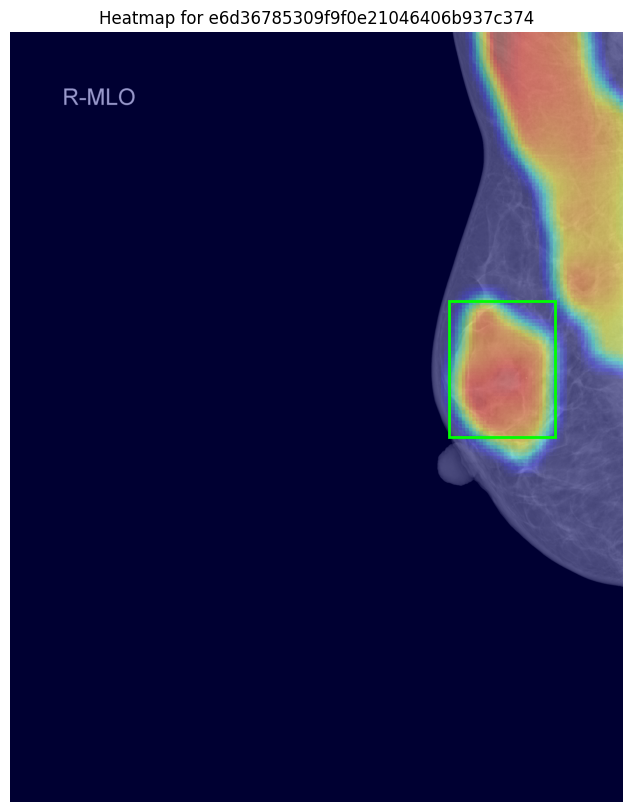

In [38]:
# -------------------
# CONFIG (adjust these)
# -------------------
Load_from_ZIP = True
zip_path = "data/vindr-mammo-a-large-scale-benchmark-dataset-for-computer-aided-detection-and-diagnosis-in-full-field-digital-mammography-1.0.0.zip"
image_folder = "data/train_images/"
patch_size = (128, 128)
stride = 16

# -------------------
# LOAD CSV (must exist already)
# -------------------
df = pd.read_csv("data/finding_annotations.csv")
df = df[['image_id','finding_categories','xmin','ymin','xmax','ymax']]

# -------------------
# BUILD IMAGE INDEX
# -------------------
image_index, z = build_image_index(
    image_folder=image_folder,
    zip_path=zip_path,
    load_from_zip=Load_from_ZIP
)

# -------------------
# HEATMAP GENERATION
# -------------------
def generate_heatmap(model, img):
    h, w = img.shape
    heatmap = np.zeros((h, w))
    counts = np.zeros((h, w))

    for y in range(0, h - patch_size[0] + 1, stride):
        for x in range(0, w - patch_size[1] + 1, stride):

            if Multi_scale_patch:
                p_small, p_large = extract_multiscale_patch(img, x, y, patch_size[0])

                p_small = np.expand_dims(p_small, axis=(0, -1))
                p_large = np.expand_dims(p_large, axis=(0, -1))

                pred = model.predict([p_small, p_large], verbose=0)[0][0]

            else:
                patch = img[y:y+patch_size[0], x:x+patch_size[1]]
                patch = np.expand_dims(patch, axis=(0, -1))

                pred = model.predict(patch, verbose=0)[0][0]

            # optional threshold stabilization
            pred = 0 if pred < 0.3 else pred

            heatmap[y:y+patch_size[0], x:x+patch_size[1]] += pred
            counts[y:y+patch_size[0], x:x+patch_size[1]] += 1

    heatmap = heatmap / (counts + 1e-6)

    return heatmap

# -------------------
# VISUALIZATION
# -------------------
def show_heatmap(model, image_id):
    img = load_image(
    image_id=image_id,
    image_index=image_index,
    load_from_zip=Load_from_ZIP,
    zip_file=z
)

    if img is None:
        print("Image not found")
        return

    heatmap = generate_heatmap(model, img)

    plt.figure(figsize=(10,10))
    plt.imshow(img, cmap='gray')

    # overlay heatmap
    plt.imshow(heatmap, cmap='jet', alpha=0.4)

    # draw GT boxes
    rows = df[df['image_id'] == image_id]

    for _, row in rows.iterrows():
        if row['finding_categories'] == "['Mass']" and not np.isnan(row['xmin']):
            x = row['xmin']
            y = row['ymin']
            w = row['xmax'] - row['xmin']
            h = row['ymax'] - row['ymin']

            rect = patches.Rectangle(
                (x, y), w, h,
                linewidth=2,
                edgecolor='lime',
                facecolor='none'
            )
            plt.gca().add_patch(rect)

    plt.title(f"Heatmap for {image_id}")
    plt.axis('off')
    plt.show()

def get_random_mass_image_id(df):
    # keep only rows with Mass and valid boxes
    mass_df = df[
        (df['finding_categories'] == "['Mass']") &
        (~df['xmin'].isna())
    ]

    if len(mass_df) == 0:
        print("No Mass images found in dataframe")
        return None

    # get unique image_ids
    image_ids = mass_df['image_id'].unique()

    # pick one randomly
    return np.random.choice(image_ids)
# -------------------
# RUN (random image)
# -------------------
image_id = get_random_mass_image_id(df)



if image_id is not None:
    print("Selected image:", image_id)
    show_heatmap(model, image_id)